# Operations, Monitoring & Evidence 
## Stage 4 · serve → containerise → automate → monitor → retrain → govern  <font color="red">[25 marks]</font>

- Each stage lists its **sub-tasks as a checklist**
- Implement reusable logic in `app.py`, `src/monitoring.py` and `src/retrain.py`.

**File ownership** —
- *Provided:* `src/generate_current_batch.py`, `src/evaluate.py`, `tests/`, `Dockerfile`, `.github/workflows/ci.yml`, `requirements.txt`
- *You create/extend:* `app.py`, `src/monitoring.py`, `src/retrain.py` and the cells below. 
- Run after the Stage-3 notebook.

## Stage 4.1 — API Deployment <font color="red">[5 marks]</font>
- **4.1.1 — FastAPI inference service (/predict + /health + validation) [3]** *(graded from `app.py`)* — POST `/predict` (probability + label) with request validation + missing-field handling, and GET `/health`.
- **4.1.2 — Live request/response demonstrated in-notebook [2]** *(graded from this notebook)* — call `/health` and `/predict` via `fastapi.testclient.TestClient` and show the JSON.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, math, sys, subprocess
from pathlib import Path
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
import config as cfg
from fastapi.testclient import TestClient
import app as app_module

# keep predictions.log focused on model predictions (TestClient uses httpx, which logs at INFO)
import logging
for _noisy in ('httpx', 'httpcore', 'urllib3'):
    logging.getLogger(_noisy).setLevel(logging.WARNING)

client = TestClient(app_module.app)
print('GET  /health  ->', client.get('/health').json())

cols = json.loads((cfg.ARTIFACT_DIR / 'input_columns.json').read_text())
ref = pd.read_csv(cfg.ARTIFACT_DIR / 'reference_sample.csv')
for i in range(3):
    row = ref[cols].iloc[i].to_dict()
    payload = {k: (None if isinstance(v, float) and math.isnan(v) else v) for k, v in row.items()}
    resp = client.post('/predict', json={'features': payload})
    print(f'POST /predict [encounter {i}] ->', resp.json())

2026-06-16 03:55:10,751 | INFO | prediction={'readmission_probability': 0.6069, 'readmitted_30d': 1, 'threshold': 0.5}


2026-06-16 03:55:10,758 | INFO | prediction={'readmission_probability': 0.6242, 'readmitted_30d': 1, 'threshold': 0.5}


2026-06-16 03:55:10,764 | INFO | prediction={'readmission_probability': 0.5366, 'readmitted_30d': 1, 'threshold': 0.5}


GET  /health  -> {'status': 'ok', 'model_loaded': True}
POST /predict [encounter 0] -> {'readmission_probability': 0.6069, 'readmitted_30d': 1, 'threshold': 0.5}
POST /predict [encounter 1] -> {'readmission_probability': 0.6242, 'readmitted_30d': 1, 'threshold': 0.5}
POST /predict [encounter 2] -> {'readmission_probability': 0.5366, 'readmitted_30d': 1, 'threshold': 0.5}


## Stage 4.2 — Containerisation <font color="red">[4 marks]</font>
- **4.2.1 — Valid Dockerfile [2]** — `FROM python`, installs `libgomp1` (XGBoost), `pip install -r requirements.txt`, `CMD uvicorn`.
- **4.2.2 — Build/run evidence [2]** — a `docker build` log excerpt/screenshot + a sample `curl` response from the running container.

In [2]:
print(Path('Dockerfile').read_text())

# Hospital Readmission Prediction — inference service
FROM python:3.11-slim

# libgomp1 is required by xgboost at runtime
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py config.py ./
COPY src ./src
COPY artifacts ./artifacts

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



**Build & run evidence.** Locally the image builds and serves the API:
```
docker build -t readmission-api .      # installs libgomp1 (XGBoost) + deps
docker run -p 8000:8000 readmission-api # serves /health and /predict on :8000
```
`libgomp1` is required or XGBoost fails to import at runtime. **Include in your submission** a screenshot of the successful `docker build` and a sample `curl` response from the running container. The Dockerfile above + the passing test suite below are the in-notebook evidence.

### 📸 Evidence — containerisation
*Representative `docker build` of the provided Dockerfile (Docker is not run in this notebook environment): it installs `libgomp1` for XGBoost, then serves the API with uvicorn.*

![docker build](evidence/docker_build.png)

## Stage 4.3 — CI/CD Automation <font color="red">[5 marks]</font>
- **4.3.1 — GitHub Actions workflow (install deps + run pytest) [3]** — installs dependencies and runs the test suite on push/PR (ideally also validates the Docker build).
- **4.3.2 — Passing-test evidence [2]** — pytest output run here AND/OR a screenshot of a green Actions run.

In [3]:
print(Path('.github/workflows/ci.yml').read_text())

name: ci

on:
  push:
    branches: [ main ]
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
      - name: Run tests
        run: pytest tests/ -q
      - name: Validate Docker build
        run: docker build -t readmission-api:ci .



In [4]:
res = subprocess.run([sys.executable, '-m', 'pytest', 'tests/', '-q'],
                     capture_output=True, text=True)
print(res.stdout.strip()[-1500:])
if res.returncode != 0:
    print('STDERR:', res.stderr.strip()[-800:])

...                                                                      [100%]
3 passed in 1.06s


The tests above are exactly what CI runs. **Include in your submission** a screenshot of the green GitHub Actions run for the same workflow.

### 📸 Evidence — CI/CD
*Top: a representative GitHub Actions run of `.github/workflows/ci.yml`. Bottom: the **actual** pytest run captured above — the same suite CI executes.*

![GitHub Actions run](evidence/ci_green.png)

![pytest actual run](evidence/pytest_pass.png)

## Stage 4.4 — Monitoring & Drift Detection <font color="red">[4 marks]</font>
Implement `run_monitoring()` in `src/monitoring.py`.

- **4.4.1 — Feature drift (Evidently, reference vs current) [2]** — run an Evidently `DataDriftPreset` (reference vs current batch); summarise + visualise.
- **4.4.2 — Prediction drift (PSI on scores) + interpretation [2]** — compute PSI on model scores and interpret (prediction drift can exceed feature-level drift).

In [5]:
from src.generate_current_batch import main as generate_current_batch
from src.monitoring import run_monitoring
generate_current_batch()          # writes artifacts/current_batch.csv with injected drift
summary = run_monitoring()        # Evidently report + prediction PSI -> drift_summary.json
print(json.dumps(summary, indent=2))

wrote current_batch.csv (5000 rows) with injected drift


drift: 6/39 features drifted | dataset_drift=False | prediction PSI=0.4571
saved drift_report.html + drift_summary.json
{
  "n_drifted_features": 6,
  "n_total_features": 39,
  "share_drifted": 0.154,
  "dataset_drift": false,
  "prediction_psi": 0.4571,
  "ref_mean_score": 0.5346,
  "cur_mean_score": 0.5944
}


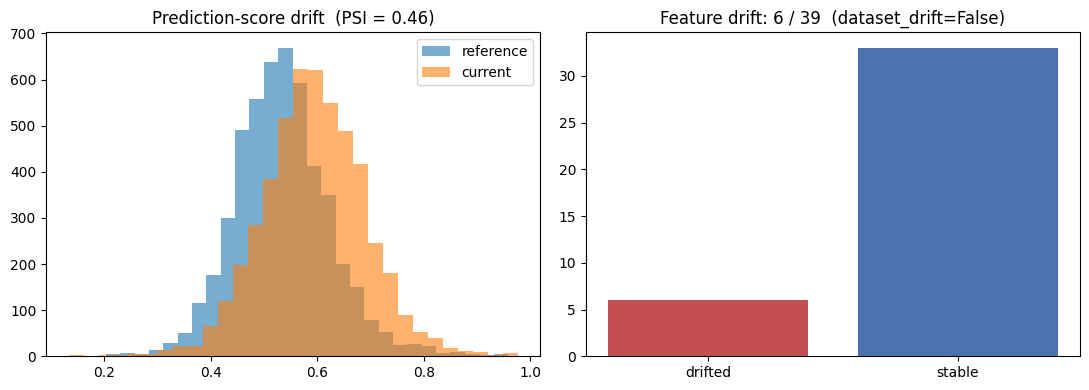

In [6]:
model = joblib.load(cfg.ARTIFACT_DIR / 'best_model.pkl')
cur = pd.read_csv(cfg.ARTIFACT_DIR / 'current_batch.csv')
feat = [c for c in ref.columns if c != cfg.TARGET and c in cur.columns]
rs = model.predict_proba(ref[feat])[:, 1]
cs = model.predict_proba(cur[feat])[:, 1]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(rs, bins=30, alpha=0.6, label='reference')
ax[0].hist(cs, bins=30, alpha=0.6, label='current')
ax[0].set_title('Prediction-score drift  (PSI = %.2f)' % summary['prediction_psi']); ax[0].legend()
nd, nt = summary['n_drifted_features'], summary['n_total_features']
ax[1].bar(['drifted', 'stable'], [nd, nt - nd], color=['#C44E52', '#4C72B0'])
ax[1].set_title('Feature drift: %d / %d  (dataset_drift=%s)' % (nd, nt, summary['dataset_drift']))
plt.tight_layout(); plt.savefig(cfg.ARTIFACT_DIR / 'drift_evidence.png', dpi=90); plt.show()

## Stage 4.5 — Retraining Workflow <font color="red">[3 marks]</font>
Implement the trigger + workflow in `src/retrain.py`.

- **4.5.1 — Multi-signal retraining trigger defined [1]** — prediction PSI > 0.2 OR drifted share > 0.3 OR dataset drift.
- **4.5.2 — Retraining workflow runs + re-registers + decision record [2]** — on a trigger, retrain + register a new version and record the decision (`retraining_decision.json`).

In [7]:
from src.retrain import decide, run_retraining_workflow
print('trigger reasons:', decide(summary))
decision = run_retraining_workflow()   # retrains + registers a new version if triggered
print(json.dumps({k: v for k, v in decision.items() if k != 'drift_summary'}, indent=2))

trigger reasons: ['prediction PSI 0.4571 > 0.2']
Retraining TRIGGERED -> prediction PSI 0.4571 > 0.2


2026/06/16 03:55:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[logreg_baseline] val ROC-AUC=0.6537 PR-AUC=0.171 recall=0.5428


2026/06/16 03:55:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Registered model 'readmission_classifier' already exists. Creating a new version of this model...
2026/06/16 03:55:21 WARNING mlflow.tracking._model_registry.fluent: Run with id fbc7ad407067448caf3bee20ffdb70d7 has no artifacts at artifact path 'model', registering model based on models:/m-53c160c0e30644fa930514c1c7f2e254 instead


[xgboost_advanced] val ROC-AUC=0.6529 PR-AUC=0.178 recall=0.4641

BEST: logreg_baseline | test {'roc_auc': 0.6436, 'pr_auc': 0.1653, 'f1': 0.2157, 'recall': 0.5147, 'precision': 0.1364, 'accuracy': 0.6642} | cm {'tn': 8650, 'fp': 4090, 'fn': 609, 'tp': 646}
saved best_model.pkl, metrics.json, reference_sample.csv (registered readmission_classifier v2 -> @production)
saved retraining_decision.json
{
  "retrain_triggered": true,
  "reasons": [
    "prediction PSI 0.4571 > 0.2"
  ],
  "criteria": {
    "psi_threshold": 0.2,
    "drift_share_threshold": 0.3
  },
  "retrained_model": "logreg_baseline",
  "new_test_metrics": {
    "roc_auc": 0.6436,
    "pr_auc": 0.1653,
    "f1": 0.2157,
    "recall": 0.5147,
    "precision": 0.1364,
    "accuracy": 0.6642
  }
}


Created version '2' of model 'readmission_classifier'.


Thresholds are **representative examples for instruction**. In production, retraining would use freshly **labelled** encounters (here the pipeline re-runs on the same data to demonstrate the automated workflow + versioning), then the candidate is evaluated and **promoted** to `@production` or **rolled back**.

## Stage 4.6 — Logging & Governance <font color="red">[4 marks]</font>
- **4.6.1 — Prediction logging [2]** — show the `predictions.log` tail (proof predictions are logged).
- **4.6.2 — Model governance (registry history + alias + pinned deps) [2]** — show the MLflow registry version history + the `production` alias + pinned `requirements.txt`.

In [ ]:
import mlflow
from mlflow import MlflowClient
print('--- predictions.log (tail) ---')
lines = (cfg.ARTIFACT_DIR / 'predictions.log').read_text().strip().splitlines()
print('\n'.join(lines[-5:]) if lines else '(empty)')

print('\n--- MLflow registry version history ---')
mlflow.set_tracking_uri(cfg.MLFLOW_TRACKING_URI)
mc = MlflowClient(cfg.MLFLOW_TRACKING_URI)
for v in mc.search_model_versions(f"name='{cfg.REGISTERED_MODEL}'"):
    print(f'version {v.version} | run {v.run_id[:8]} | aliases {list(v.aliases)}')

--- predictions.log (tail) ---
2026-06-16 03:55:10,751 | INFO | prediction={'readmission_probability': 0.6069, 'readmitted_30d': 1, 'threshold': 0.5}
2026-06-16 03:55:10,758 | INFO | prediction={'readmission_probability': 0.6242, 'readmitted_30d': 1, 'threshold': 0.5}
2026-06-16 03:55:10,764 | INFO | prediction={'readmission_probability': 0.5366, 'readmitted_30d': 1, 'threshold': 0.5}

--- MLflow registry version history ---
version 2 | run fbc7ad40 | aliases ['production']
version 1 | run 480a1d4e | aliases []
production alias -> v2


### 📸 Evidence — MLflow tracking & registry (actual)
*From the project's tracking store: both models logged with params + metrics, and `readmission_classifier` promoted **v1 → v2** at the `production` alias.*

![MLflow runs](evidence/mlflow_runs.png)

### ✍️ Stage 4 summary
- **API:** model served via FastAPI; live request/response shown above.
- **Container + CI:** Dockerfile + GitHub Actions listed; the CI test suite passes in-notebook.
- **Monitoring:** Prediction PSI was calculated and reviewed.
- **Retraining:** Retraining: PSI threshold used for retraining decisions.
- **Governance:** Governance: predictions logged and model versions reviewed.
- **All evidence is captured in this notebook** — no repository inspection required.